In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path


In [2]:
# Set paths to project folders
path_data = Path("../../1-Climate Finance Project")
# print(os.listdir(path_data))

# working directory analysis
wd_analysis = path_data / "Data" / "3-Analysis"

# Read data
analysis_df = pd.read_csv(wd_analysis / "Finance_Disaster_Analysis.csv")
analysis_df["month"] = pd.to_datetime(analysis_df["month"])

In [3]:
# Count number of treated and controled groups
analysis_df["event_occur"].value_counts(dropna=False)

event_occur
0.0    72735
1.0     1164
Name: count, dtype: int64

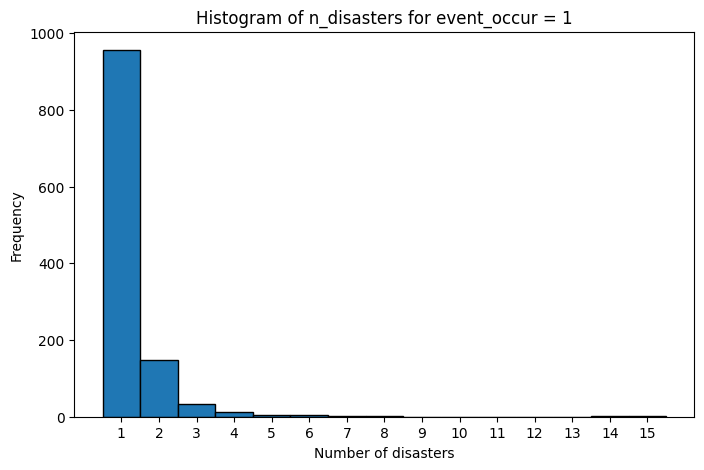

In [4]:
x = analysis_df.loc[analysis_df["event_occur"] == 1, "n_disasters"].dropna()

plt.figure(figsize=(8, 5))
plt.hist(x, bins=np.arange(x.min(), x.max() + 2) - 0.5, edgecolor="black")
plt.xlabel("Number of disasters")
plt.ylabel("Frequency")
plt.title("Histogram of n_disasters for event_occur = 1")
plt.xticks(range(int(x.min()), int(x.max()) + 1))
plt.show()

Is this something we should be concerned? 

In [5]:
# Top disasters
type_counts = {
    "Hurricane": analysis_df["n_hurricane"].sum(),
    "Tornado": analysis_df["n_tornado"].sum(),
    "Tropical Storm": analysis_df["n_tropical_storm"].sum(),
    "Thunderstorm": analysis_df["n_thunderstorm"].sum(),
    "Flood": analysis_df["n_flood"].sum(),
    "Winter Weather": analysis_df["n_winter_weather"].sum(),
    "Wildfire": analysis_df["n_wildfire"].sum(),
    "Hail": analysis_df["n_hail"].sum(),
}
print(pd.Series(type_counts).sort_values(ascending=False))

Flood             706.0
Tornado           346.0
Thunderstorm      229.0
Hail              132.0
Tropical Storm     43.0
Hurricane          33.0
Wildfire           18.0
Winter Weather      0.0
dtype: float64


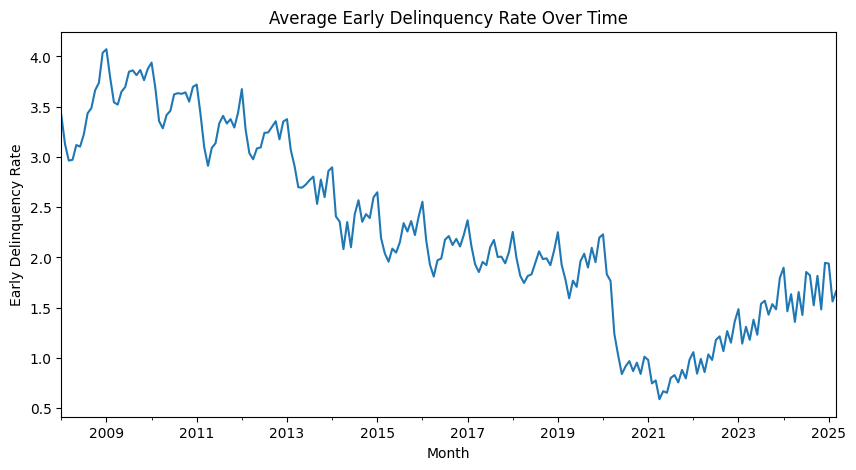

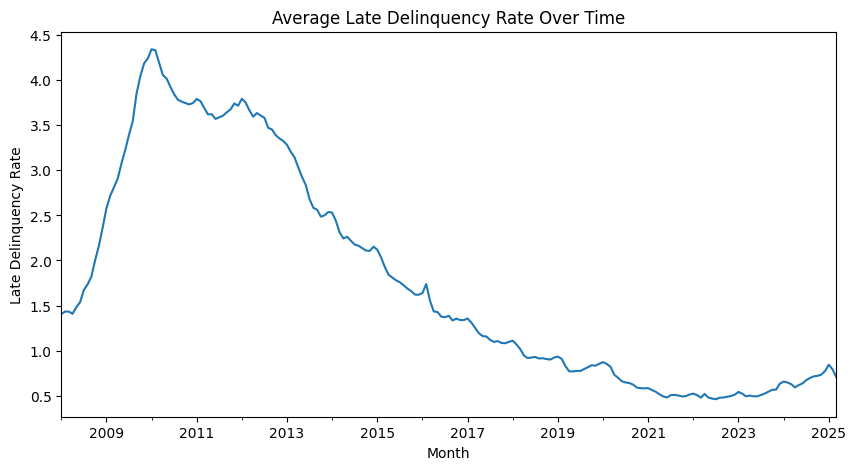

In [6]:
# average delinquency over time

monthly_avg=analysis_df.groupby("month")[["Early_Delinquency_Rate", "Late_Delinquency_Rate"]].mean()

monthly_avg["Early_Delinquency_Rate"].plot(figsize=(10, 5))
plt.title("Average Early Delinquency Rate Over Time")
plt.ylabel("Early Delinquency Rate")
plt.xlabel("Month")
plt.show()

monthly_avg["Late_Delinquency_Rate"].plot(figsize=(10, 5))
plt.title("Average Late Delinquency Rate Over Time")
plt.ylabel("Late Delinquency Rate")
plt.xlabel("Month")
plt.show()

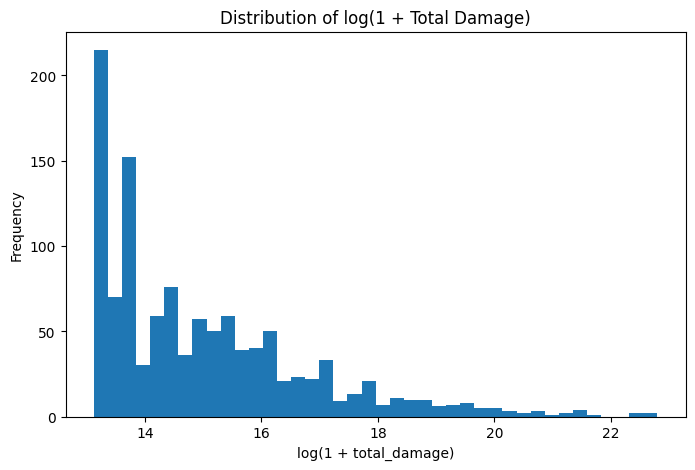

In [7]:
#damage histogram on log scale


treated_damage = analysis_df.loc[analysis_df["event_occur"] == 1, "total_damage"]

plt.figure(figsize=(8, 5))
plt.hist(np.log1p(treated_damage), bins=40)
plt.title("Distribution of log(1 + Total Damage)")
plt.xlabel("log(1 + total_damage)")
plt.ylabel("Frequency")
plt.show()

# Log scale is best since most of the losses reported are closed to 0

             Early_Delinquency_Rate  Late_Delinquency_Rate
event_occur                                               
0.0                        2.276751               1.772074
1.0                        2.477320               1.921306


<Figure size 800x500 with 0 Axes>

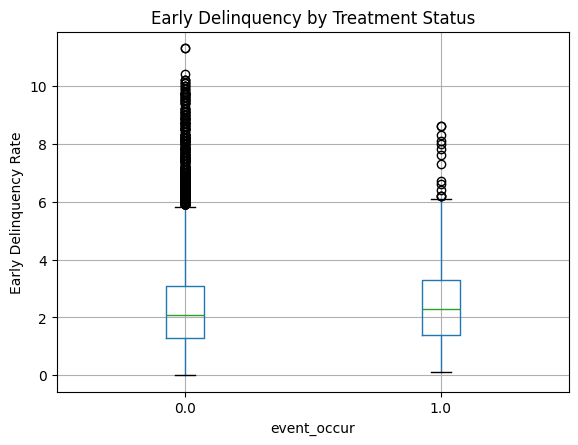

<Figure size 800x500 with 0 Axes>

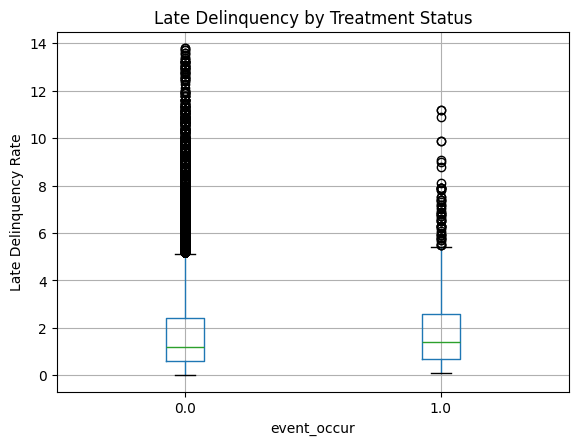

In [8]:
#mean delinquency in treated vs untreated county-months

comparison = analysis_df.groupby("event_occur")[["Early_Delinquency_Rate", "Late_Delinquency_Rate"]].mean()
print(comparison)


plt.figure(figsize=(8, 5))
analysis_df.boxplot(column="Early_Delinquency_Rate", by="event_occur")
plt.title("Early Delinquency by Treatment Status")
plt.suptitle("")
plt.xlabel("event_occur")
plt.ylabel("Early Delinquency Rate")
plt.show()

plt.figure(figsize=(8, 5))
analysis_df.boxplot(column="Late_Delinquency_Rate", by="event_occur")
plt.title("Late Delinquency by Treatment Status")
plt.suptitle("")
plt.xlabel("event_occur")
plt.ylabel("Late Delinquency Rate")
plt.show()

# We have a lots of outliers

In [9]:
# How many counties are ever treated?
treated_counties = analysis_df.loc[analysis_df["event_occur"] == 1, "fips"].nunique()
print("Counties ever treated:", treated_counties)
print("Share of counties ever treated:", treated_counties / analysis_df["fips"].nunique())

Counties ever treated: 325
Share of counties ever treated: 0.9103641456582633


In [10]:
# Counties that experienced most events
county_treatment_counts = (
    analysis_df.groupby("fips")["event_occur"]
    .sum()
    .sort_values(ascending=False)
)

print(county_treatment_counts.describe())
print(county_treatment_counts.head(20))

count    357.000000
mean       3.260504
std        2.547731
min        0.000000
25%        2.000000
50%        3.000000
75%        5.000000
max       15.000000
Name: event_occur, dtype: float64
fips
48303    15.0
28121    14.0
4019     13.0
47037    13.0
12127    13.0
48453    12.0
26081    10.0
22015    10.0
13139    10.0
37183     9.0
39153     9.0
47125     9.0
22055     9.0
26163     9.0
47189     9.0
48245     9.0
4025      8.0
29183     8.0
12011     8.0
12115     8.0
Name: event_occur, dtype: float64


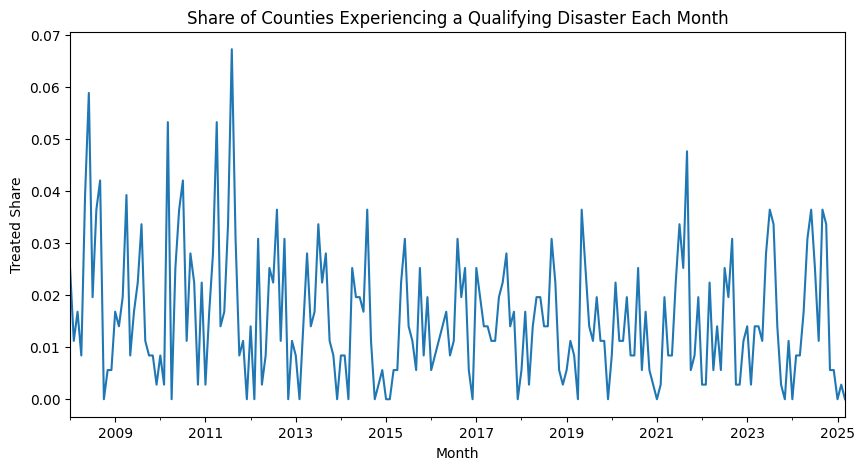

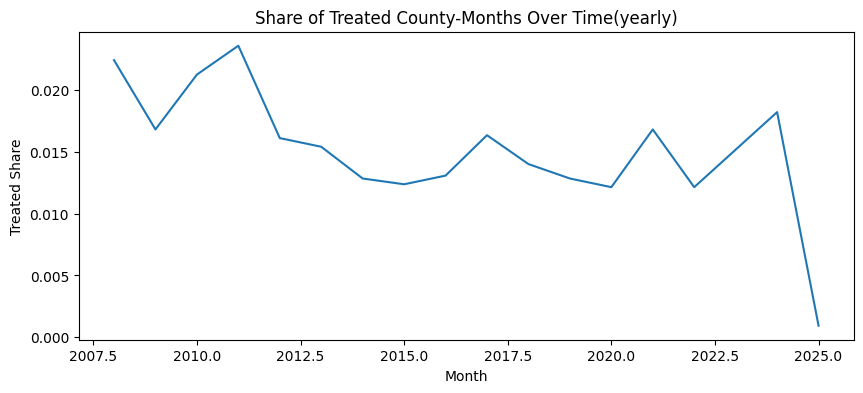

In [11]:
# Monthly treatment rate

monthly_treat = analysis_df.groupby("month")["event_occur"].mean()

yearly_treatment = analysis_df.groupby(analysis_df["month"].dt.year)["event_occur"].mean()

monthly_treat.plot(figsize=(10, 5))
plt.title("Share of Counties Experiencing a Qualifying Disaster Each Month")
plt.ylabel("Treated Share")
plt.xlabel("Month")
plt.show()

#yearly treatment rate
yearly_treatment.plot(figsize=(10, 4))
plt.title("Share of Treated County-Months Over Time(yearly)")
plt.ylabel("Treated Share")
plt.xlabel("Month")
plt.show()

Treatment is rare in time, but common across counties

- Only ~1.46% of county-months are treated

- About 89.6% of counties are treated at least once

This is an important design insight. Your identification will come mostly from:

 - within-county timing

 - not from a large pool of never-treated counties

That fits a fixed-effects framework well.

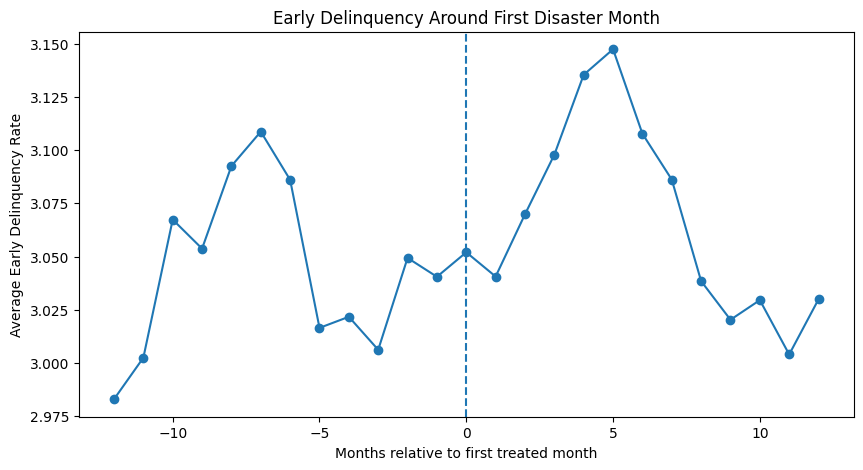

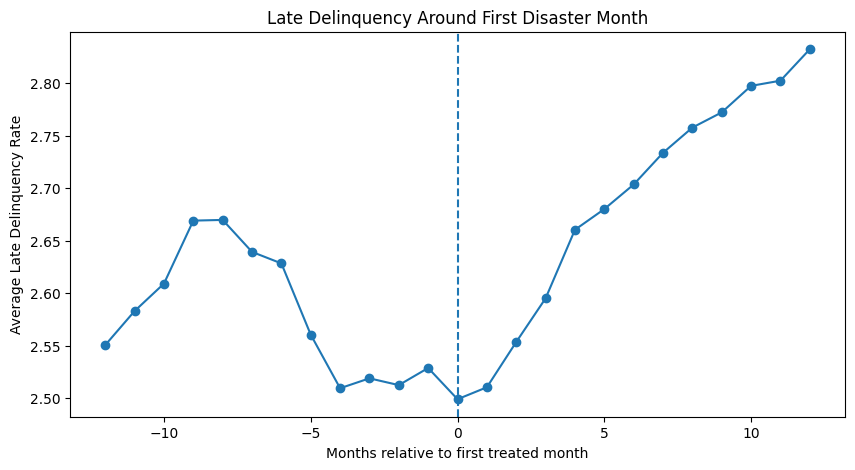

In [12]:
df = analysis_df.copy()
df["month"] = pd.to_datetime(df["month"])

# first treated month by county
first_treat = (
    df.loc[df["event_occur"] == 1]
    .groupby("fips")["month"]
    .min()
    .rename("first_treat_month")
)

df = df.merge(first_treat, on="fips", how="left")

# event time in months
df["event_time"] = (
    (df["month"].dt.year - df["first_treat_month"].dt.year) * 12 +
    (df["month"].dt.month - df["first_treat_month"].dt.month)
)

# keep window
event_window = df[df["event_time"].between(-12, 12)].copy()

# average outcomes by event time
es_early = event_window.groupby("event_time")["Early_Delinquency_Rate"].mean()
es_late = event_window.groupby("event_time")["Late_Delinquency_Rate"].mean()

plt.figure(figsize=(10, 5))
plt.plot(es_early.index, es_early.values, marker="o")
plt.axvline(0, linestyle="--")
plt.title("Early Delinquency Around First Disaster Month")
plt.xlabel("Months relative to first treated month")
plt.ylabel("Average Early Delinquency Rate")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(es_late.index, es_late.values, marker="o")
plt.axvline(0, linestyle="--")
plt.title("Late Delinquency Around First Disaster Month")
plt.xlabel("Months relative to first treated month")
plt.ylabel("Average Late Delinquency Rate")
plt.show()

Let's normalize by county baseline, so cross-county level differences do not dominate.

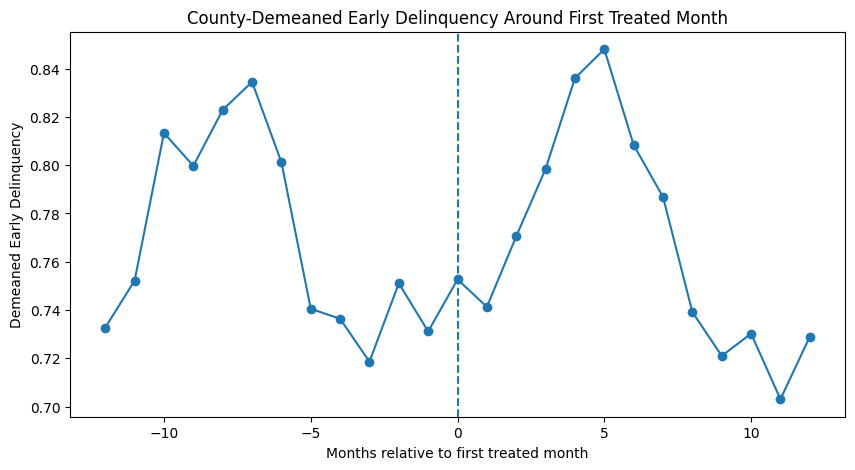

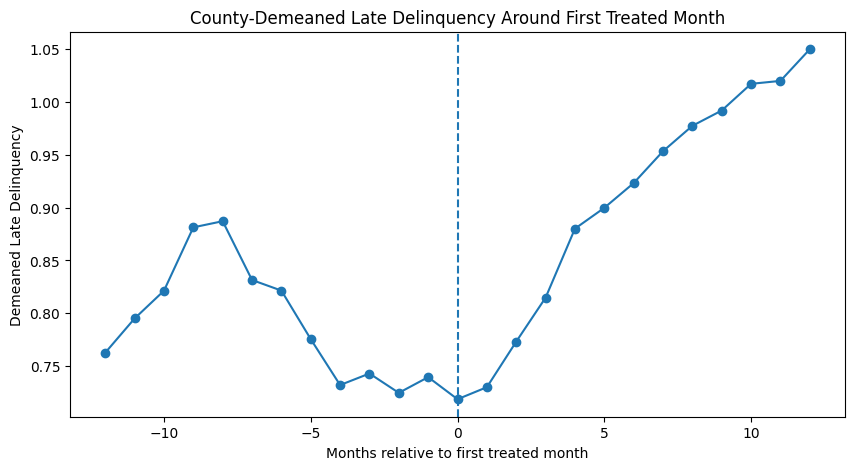

In [13]:
county_means = df.groupby("fips")[["Early_Delinquency_Rate", "Late_Delinquency_Rate"]].mean()
county_means = county_means.rename(columns={
    "Early_Delinquency_Rate": "Early_mean_county",
    "Late_Delinquency_Rate": "Late_mean_county"
})

df = df.merge(county_means, on="fips", how="left")
df["Early_demeaned"] = df["Early_Delinquency_Rate"] - df["Early_mean_county"]
df["Late_demeaned"] = df["Late_Delinquency_Rate"] - df["Late_mean_county"]

event_window = df[df["event_time"].between(-12, 12)].copy()

es_early_dm = event_window.groupby("event_time")["Early_demeaned"].mean()
es_late_dm = event_window.groupby("event_time")["Late_demeaned"].mean()

plt.figure(figsize=(10, 5))
plt.plot(es_early_dm.index, es_early_dm.values, marker="o")
plt.axvline(0, linestyle="--")
plt.title("County-Demeaned Early Delinquency Around First Treated Month")
plt.xlabel("Months relative to first treated month")
plt.ylabel("Demeaned Early Delinquency")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(es_late_dm.index, es_late_dm.values, marker="o")
plt.axvline(0, linestyle="--")
plt.title("County-Demeaned Late Delinquency Around First Treated Month")
plt.xlabel("Months relative to first treated month")
plt.ylabel("Demeaned Late Delinquency")
plt.show()

This shows something very important:

- the treatment is rare over time,

- but fairly widespread across space.

That means identification does not come mainly from comparing treated counties to never-treated counties, but rather from within-county variation over time. That strongly supports a fixed effects approach.